In [1]:
from utils import preprocessing
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import rpy2.robjects as ro
r = ro.r


# Observe zones in BICAN (inyl Healthy)

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


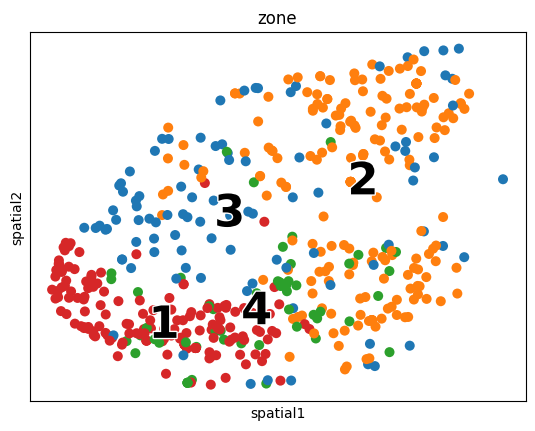

In [ ]:
# adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/STR_D1D2_Hybrid_MSN_4_zones.h5ad")
# adata.obsm["spatial"] = np.array([adata.obs["x"], adata.obs["y"]]).T
# adata.obs["zone"] = adata.obs["Final_Zone_Assignments_No_Smooth"].astype("category")
# adata = adata[~(adata.obs["donor_id"] == 'nan'), :].copy()  # remove cells with missing donor_id
# sc.pl.embedding(
#     adata[adata.obs["donor_id"] == adata.obs["donor_id"].unique()[0]],
#     basis="spatial",
#     color="zone",
#     legend_loc="on data",
#     legend_fontsize=32,        # bump this up
#     legend_fontoutline=2,      # optional: outline so labels stay readable on the dots
# )

In [2]:
# creating  bican spatial d1d2 6 zones
qs_path     = "/home/gdallagl/myworkdir/XDP/data/BICAN/ESPN_6_zones_reordered.qs" #"/home/gdallagl/myworkdir/XDP/data/BICAN/D1_matrix_6_clusters_no56.qs"      # input Seurat object
PATH_BASE   = "/home/gdallagl/myworkdir/XDP/data/_tmp"  # scratch folder for the .mtx/.txt/.csv
saving_path = "/home/gdallagl/myworkdir/XDP/data/BICAN/ESPN_6_zones_reordered.h5ad"       # final h5ad

# Step 1: R reads the .qs and dumps counts + metadata to flat files
preprocessing.read_qs_save_files(qs_path, PATH_BASE, assay="RNA")

# Step 2: Python reads those flat files and builds the h5ad
adata = preprocessing.build_h5ad_from_files(PATH_BASE, saving_path)

adata.obsm["spatial"] = np.array([adata.obs["x"], adata.obs["y"]]).T
adata.obs["zone"] = adata.obs["Final_Zone_Assignments_No_Smooth"].astype("Int64").astype("category")

adata = adata[~(adata.obs["zone"].isna()), :].copy()  # remove cells with missing zone annotation
adata = adata[~(adata.obs["donor_id"] == 'nan'), :].copy()  # remove cells with missing donor_id

adata.write_h5ad(saving_path)

adata

R callback write-console: Loading required package: SeuratObject
  
R callback write-console: Loading required package: sp
  
R callback write-console: 
Attaching package: ‘SeuratObject’

  
R callback write-console: The following objects are masked from ‘package:base’:

    %||%, intersect, t

  



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

R callback write-console: 
Attaching package: ‘Seurat’

  
R callback write-console: The following object is masked from ‘package:base’:

    %||%

  
R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  


Seurat version: 5.4.0 
Detected Seurat v5 assay


/home/gdallagl/myworkdir/XDP/utils/preprocessing.py:146: DtypeWarning: Columns (4,5,18,19,20,37,49,50,52,84,94,96,97,98,109,111,118,120,121,122,133,135,142,144,145,156,158,165,167,168,179,181,198,199) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f"{PATH_BASE}/metadata.csv", index_col=0)


AnnData object with n_obs × n_vars = 4347 × 37927
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'AK_celltype', 'RNA_snn_res.0.2', 'cb', 'clusters', 'num_dbscan', 'log

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/merge.py:1666: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/merge.py:1666: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/merge.py:1666: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA e

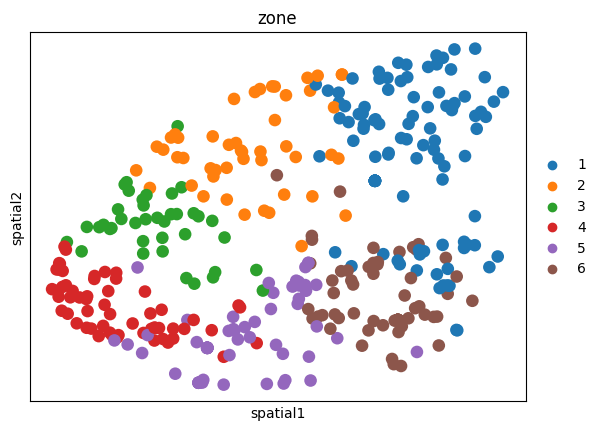

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


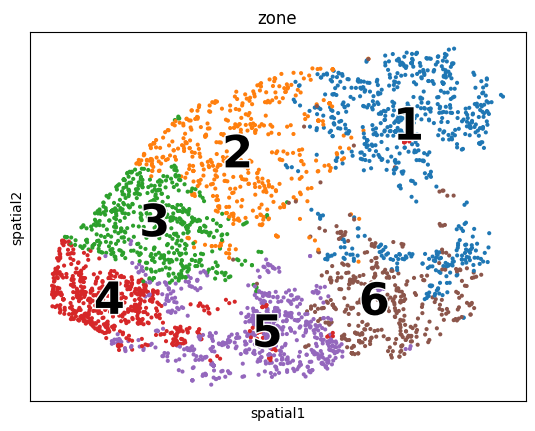

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


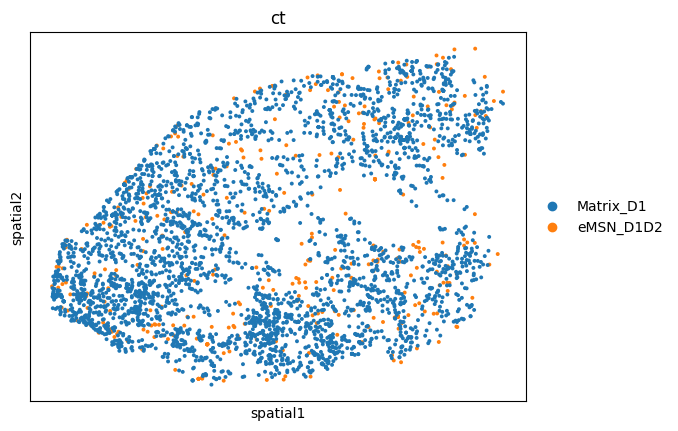

In [3]:
# rradi bicna d1d2 and matrix
adata_d1d2 = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/ESPN_6_zones_reordered.h5ad")
adata_d1d2.obs["ct"] = "eMSN_D1D2"
adata_m1 = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/D1_matrix_6_clusters_no56.h5ad")
adata_m1.obs["ct"] = "Matrix_D1"

adata_m1.obs["zone"] = adata_m1.obs["zone"].astype("Int64").astype("category")  # copy over zone annotations for coloring
adata_d1d2.obs["zone"] = adata_d1d2.obs["zone"].astype("Int64").astype("category")  # copy over zone annotations for coloring

adata_d1d2 = adata_d1d2[~(adata_d1d2.obs["zone"].isna()), :].copy()  # remove cells with missing zone annotation
adata_d1d2 = adata_d1d2[~(adata_d1d2.obs["donor_id"] == 'nan'), :].copy()  # remove cells with missing donor_id
adata_m1 = adata_m1[~(adata_m1.obs["zone"].isna()), :].copy()  # remove cells with missing zone annotation
adata_m1 = adata_m1[~(adata_m1.obs["donor_id"] == 'nan'), :].copy()  # remove cells with missing donor_id

adata = sc.concat([adata_d1d2, adata_m1], axis=0)

sc.pl.embedding(adata_d1d2[adata_d1d2.obs["donor_id"] == adata_d1d2.obs["donor_id"].unique()[0]], basis="spatial", color="zone")
sc.pl.embedding(adata_m1[adata_m1.obs["donor_id"] == adata_m1.obs["donor_id"].unique()[0]], basis="spatial", color="zone",    legend_loc="on data", legend_fontsize=32,        # bump this up
    legend_fontoutline=2,      # optional: outline so labels stay readable on the dots
)
sc.pl.embedding(adata[adata.obs["donor_id"] == adata.obs["donor_id"].unique()[0]], basis="spatial", color="ct")

### Coocrrence betwen healthjy and dieaes

In [4]:
import scanpy as sc
import squidpy as sq
import numpy as np, pandas as pd

# drop cells with no zone, then coerce to int so the comparison matches
adata_d1d2 = adata_d1d2[adata_d1d2.obs["zone"].notna()].copy()
adata_m1   = adata_m1[adata_m1.obs["zone"].notna()].copy()

zd = adata_d1d2.obs["zone"].astype(float).astype(int)
adata_d1d2.obs["cell_label"] = np.where(zd == 2, "dorsal_D1D2", "ventral_D1D2")

zm = adata_m1.obs["zone"].astype(float).astype(int)
adata_m1.obs["cell_label"] = np.where(zm.isin([1, 2, 6]), "dorsal_M1", "ventral_M1")

# merge and drop cells with missing spatial coordinates
adata_merged = sc.concat([adata_d1d2, adata_m1])
adata_merged = adata_merged[~adata_merged.obs["x"].isna(), :].copy()
ctrl_merged  = adata_merged
ctrl_merged.obs["cell_label"] = ctrl_merged.obs["cell_label"].astype("category")

pairs = [
    ("dorsal_D1D2", "dorsal_M1"),
    ("dorsal_D1D2", "ventral_M1"),
    ("ventral_D1D2", "ventral_M1"),
]

def cooc_score(adata, pair, n_splits=50):
    if adata.n_obs < 30:
        return np.nan
    adata.obs["cell_label"] = (
        adata.obs["cell_label"].astype("category").cat.remove_unused_categories()
    )
    labels = adata.obs["cell_label"].cat.categories.tolist()
    if pair[0] not in labels or pair[1] not in labels:
        return np.nan
    sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
    sq.gr.co_occurrence(adata, cluster_key="cell_label", n_splits=n_splits)
    occ  = adata.uns["cell_label_co_occurrence"]["occ"]
    i, j = labels.index(pair[0]), labels.index(pair[1])
    return float(np.nanmean(occ[i, j, :]))

rows = []
for donor in ctrl_merged.obs["donor_id"].unique():
    adata_d = ctrl_merged[ctrl_merged.obs["donor_id"] == donor].copy()
    row = {"donor": donor}
    for pair in pairs:
        row[f"{pair[0]}×{pair[1]}"] = cooc_score(adata_d, pair)
    rows.append(row)

results_ctrl = pd.DataFrame(rows).set_index("donor")
display(results_ctrl)
display(results_ctrl.mean().rename("mean score"))

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/merge.py:1666: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no l

KeyboardInterrupt: 

# Compare shift in distribution H-D using NucSeq data

In [5]:
adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad", backed="r")

# Subset to 2 zonabel cell types
adata = adata[adata.obs["ct_for_deg"].isin(["Matrix_D1", "eMSN_D1D2"]), :].to_memory().copy()

obs = adata.obs
drop = (
    (obs["ct_for_deg"] == "Matrix_D1") & obs["zone"].isna()
) | (
    (obs["ct_for_deg"] == "eMSN_D1D2") & obs["zone_4"].isna()
)
adata = adata[~drop, :].copy()

adata

AnnData object with n_obs × n_vars = 13565 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_ons

In [6]:
adata.obs["zone"] = adata.obs["zone"].astype(str)
adata.obs.loc[adata.obs["ct_for_deg"].isin(["eMSN_D1D2"]), "zone"] = adata.obs.loc[adata.obs["ct_for_deg"].isin(["eMSN_D1D2"]), "zone_4"]
adata.obs.groupby(["ct_for_deg", "zone"]).size()

/tmp/ipykernel_2039550/3496790474.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["ct_for_deg", "zone"]).size()


ct_for_deg  zone
Matrix_D1   1       1440
            2       1899
            3       1826
            4       1293
            5       2775
            6       1759
eMSN_D1D2   1        629
            2        757
            3        691
            4        496
            5          0
            6          0
dtype: int64

In [ ]:
# adata = adata[adata.obs["donor_id"].isin(l), :].copy()

In [7]:
adata_d1d2 = adata[adata.obs["ct_for_deg"] == "eMSN_D1D2", :].copy()
adata_m1 = adata[adata.obs["ct_for_deg"] == "Matrix_D1", :].copy()

## Analysis on Nucseq

/tmp/ipykernel_2039550/3850680241.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d1d2_per_sample = adata_d1d2.obs.groupby(["donor_id", "zone"]).size().unstack(fill_value=0)
/tmp/ipykernel_2039550/3850680241.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m1_per_sample   = adata_m1.obs.groupby(["donor_id", "zone"]).size().unstack(fill_value=0)


zone,1,2,3,4
donor_id,,,,
PCMC-16-011,4,1,2,5
PCMC-16-012,9,28,7,12
SCF-18-003,39,36,36,33
SCF-18-004,5,4,20,5
SCF-18-006,26,8,10,13
SCF-19-009,13,17,19,6
SCF-19-014,7,29,23,8
SCF-19-018,20,5,7,9
SCF-19-020,35,10,33,15


zone,1,2,3,4,5,6
donor_id,,,,,,
PCMC-16-011,0,2,16,19,49,21
PCMC-16-012,0,0,8,15,28,6
SCF-18-003,0,0,9,53,96,6
SCF-18-004,0,0,6,7,26,2
SCF-18-006,0,1,26,96,73,4
SCF-19-009,4,7,23,11,68,24
SCF-19-014,10,17,18,11,57,65
SCF-19-018,0,0,18,43,112,6
SCF-19-020,0,2,31,74,99,3


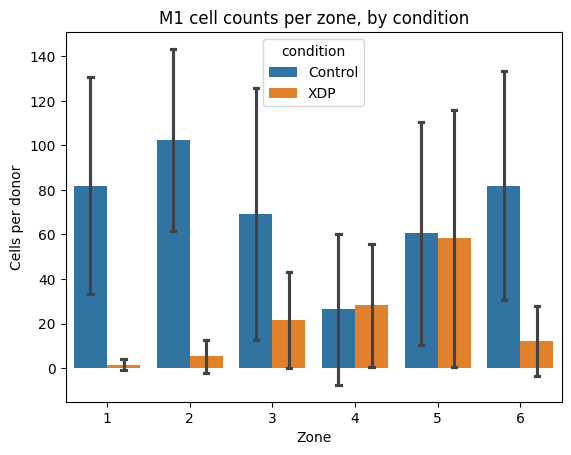

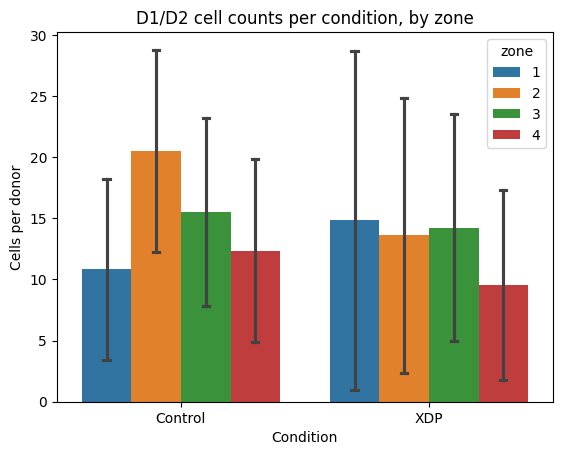

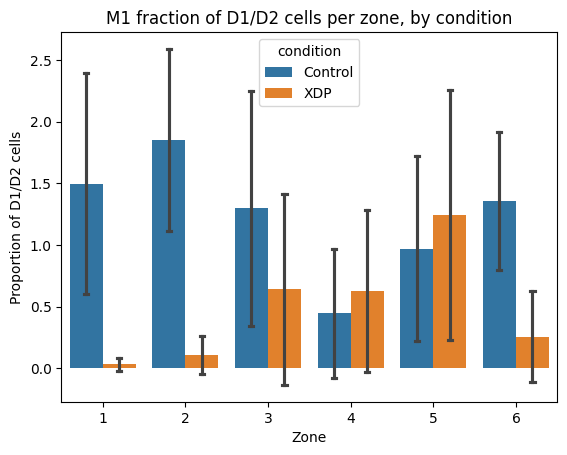

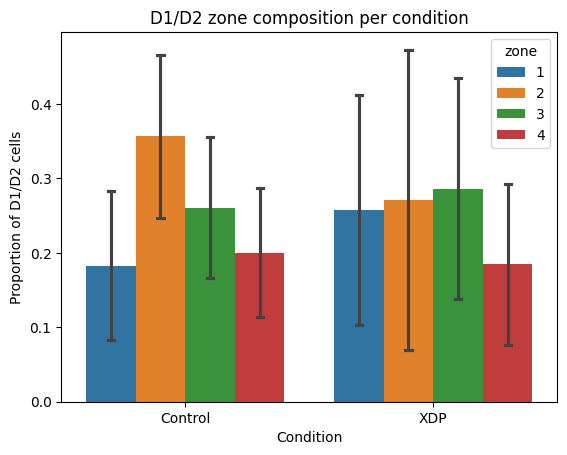

In [8]:
# How many cells per zone per donor
d1d2_per_sample = adata_d1d2.obs.groupby(["donor_id", "zone"]).size().unstack(fill_value=0)
m1_per_sample   = adata_m1.obs.groupby(["donor_id", "zone"]).size().unstack(fill_value=0)
display(d1d2_per_sample)
display(m1_per_sample)

# M1 counts: zones on x, split by condition
p_long = pd.melt(m1_per_sample.reset_index(), id_vars="donor_id", var_name="zone", value_name="counts")
p_long = p_long.merge(adata.obs[["donor_id", "condition"]].drop_duplicates(), on="donor_id")
sns.barplot(data=p_long, x="zone", y="counts", errorbar="sd", capsize=0.1, hue="condition")
plt.title("M1 cell counts per zone, by condition"); plt.xlabel("Zone"); plt.ylabel("Cells per donor"); plt.show()

# D1/D2 counts: conditions on x, split by zone
p_long = pd.melt(d1d2_per_sample.reset_index(), id_vars="donor_id", var_name="zone", value_name="counts")
p_long = p_long.merge(adata.obs[["donor_id", "condition"]].drop_duplicates(), on="donor_id")
sns.barplot(data=p_long, x="condition", y="counts", errorbar="sd", capsize=0.1, hue="zone")
plt.title("D1/D2 cell counts per condition, by zone"); plt.xlabel("Condition"); plt.ylabel("Cells per donor"); plt.show()

# Proportion per donor (denominator is total D1/D2 per sample)
proportions = m1_per_sample.div(d1d2_per_sample.sum(axis=1), axis=0)
p_long = pd.melt(proportions.reset_index(), id_vars="donor_id", var_name="zone", value_name="proportion")
p_long = p_long.merge(adata.obs[["donor_id", "condition"]].drop_duplicates(), on="donor_id")
sns.barplot(data=p_long, x="zone", y="proportion", errorbar="sd", capsize=0.1, hue="condition")
plt.title("M1 fraction of D1/D2 cells per zone, by condition"); plt.xlabel("Zone"); plt.ylabel("Proportion of D1/D2 cells"); plt.show()

proportions = d1d2_per_sample.div(d1d2_per_sample.sum(axis=1), axis=0)
p_long = pd.melt(proportions.reset_index(), id_vars="donor_id", var_name="zone", value_name="proportion")
p_long = p_long.merge(adata.obs[["donor_id", "condition"]].drop_duplicates(), on="donor_id")
sns.barplot(data=p_long, x="condition", y="proportion", errorbar="sd", capsize=0.1, hue="zone")
plt.title("D1/D2 zone composition per condition"); plt.xlabel("Condition"); plt.ylabel("Proportion of D1/D2 cells"); plt.show()

/tmp/ipykernel_2039550/418733428.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = p_long.groupby("condition")["proportion"].median()


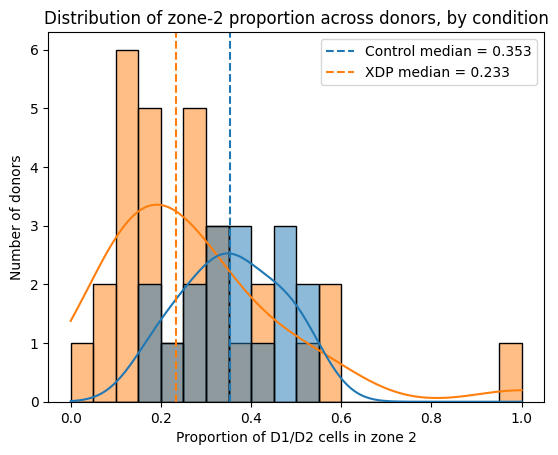

In [9]:
# Proportion of D1/D2 cells in zone 2 per donor, distribution by condition
proportions = d1d2_per_sample[["2"]].div(d1d2_per_sample.sum(axis=1), axis=0)
p_long = pd.melt(proportions.reset_index(), id_vars="donor_id", var_name="zone", value_name="proportion")
p_long = p_long.merge(adata.obs[["donor_id", "condition"]].drop_duplicates(), on="donor_id")

sns.histplot(p_long, x="proportion", kde=True, bins=20, hue="condition")

# Vertical line at each condition's median
medians = p_long.groupby("condition")["proportion"].median()
colors = dict(zip(medians.index, sns.color_palette(n_colors=len(medians))))
for cond, m in medians.items():
    plt.axvline(m, color=colors[cond], linestyle="--", label=f"{cond} median = {m:.3f}")

plt.legend()
plt.title("Distribution of zone-2 proportion across donors, by condition"); plt.xlabel("Proportion of D1/D2 cells in zone 2"); plt.ylabel("Number of donors"); plt.show()

In [ ]:
# list of doenor that have propriton of d1d2 in same range iof helathy dosnors
l = proportions[proportions["2"].between(0.1, 0.6)].index.to_list()

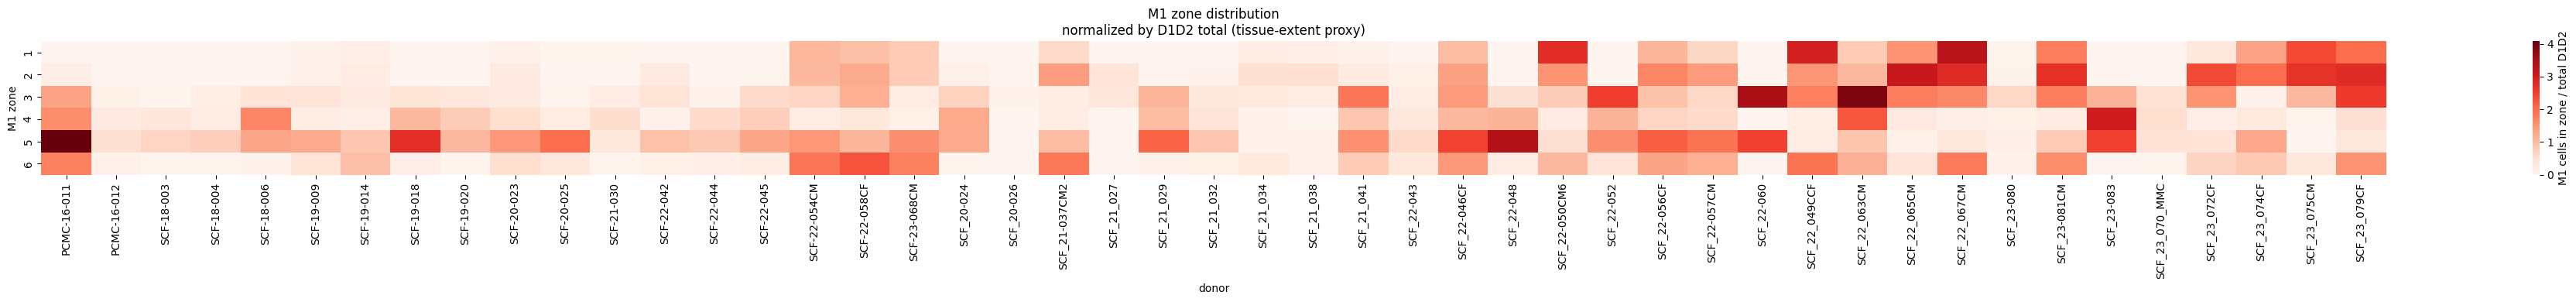

In [10]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# score(zone_i, sample_j) = M1 cells in zone_i, sample_j / total D1D2 cells in sample_j

# --- align to donors present in both datasets ---
shared_donors = m1_per_sample.index.intersection(d1d2_per_sample.index)
m1   = m1_per_sample.loc[shared_donors]
d1d2 = d1d2_per_sample.loc[shared_donors]

# --- D1D2 total per donor = proxy for how much striatum was captured ---
# D1D2 cells are assumed stable (no degeneration), so their total count
# reflects tissue extent, not biology. Using it as denominator removes
# the "incomplete image" confound.
d1d2_total = d1d2.sum(axis=1)          # Series: donor → total D1D2 cells

# --- normalize M1 zone counts by D1D2 total ---
# m1_norm[donor, zone_i] = M1 cells in zone_i / total D1D2 in that donor
# residual variation is biological, not sampling
m1_norm = m1.div(d1d2_total, axis=0)   # shape: donors × M1_zones

# --- heatmap: M1 zones (rows) × donors (cols) ---
fig, ax = plt.subplots(figsize=(len(shared_donors) * 0.8 + 1, 4))
sns.heatmap(
    m1_norm.T,                          # transpose: zones as rows, donors as cols
    cmap="Reds",
    cbar_kws={"label": "M1 cells in zone / total D1D2"},
    ax=ax
)
ax.set_title("M1 zone distribution\nnormalized by D1D2 total (tissue-extent proxy)")
ax.set_xlabel("donor")
ax.set_ylabel("M1 zone")
plt.tight_layout()
plt.show()

zone,1,2,3,4,5,6,condition
donor_id,,,,,,,
PCMC-16-011,0.000000,0.166667,1.333333,1.583333,4.083333,1.750000,XDP
PCMC-16-012,0.000000,0.000000,0.142857,0.267857,0.500000,0.107143,XDP
SCF-18-003,0.000000,0.000000,0.062500,0.368056,0.666667,0.041667,XDP
SCF-18-004,0.000000,0.000000,0.176471,0.205882,0.764706,0.058824,XDP
SCF-18-006,0.000000,0.017544,0.456140,1.684211,1.280702,0.070175,XDP
SCF-19-009,0.072727,0.127273,0.418182,0.200000,1.236364,0.436364,XDP
SCF-19-014,0.149254,0.253731,0.268657,0.164179,0.850746,0.970149,XDP
SCF-19-018,0.000000,0.000000,0.439024,1.048780,2.731707,0.146341,XDP
SCF-19-020,0.000000,0.021505,0.333333,0.795699,1.064516,0.032258,XDP


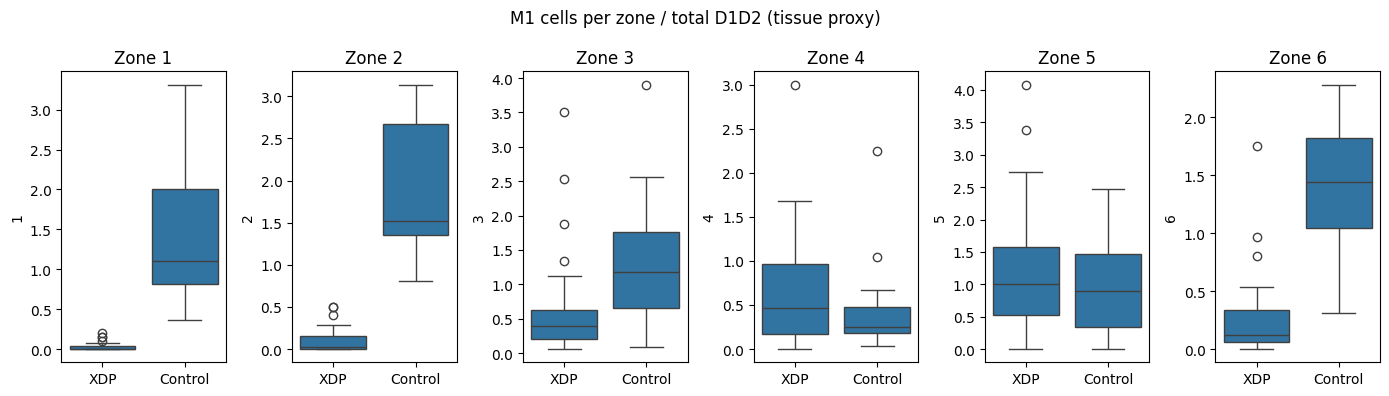

In [15]:
import matplotlib.pyplot as plt

condition_map = (
    adata.obs.drop_duplicates("donor_id")[["donor_id", "condition"]]
    .set_index("donor_id")["condition"]
    .to_dict()
)
condition_map

m1_norm_clean = m1_norm.copy()
m1_norm_clean["condition"] = m1_norm_clean.index.map(condition_map)
display(m1_norm_clean)

# compare per zone between conditions
fig, axes = plt.subplots(1, len(m1.columns), figsize=(14, 4), sharey=False)
for ax, zone in zip(axes, m1.columns):
    data = m1_norm_clean[["condition", zone]].copy()
    import seaborn as sns
    sns.boxplot(data=data, x="condition", y=zone, ax=ax)
    ax.set_title(f"Zone {zone}")
    ax.set_xlabel("")
plt.suptitle("M1 cells per zone / total D1D2 (tissue proxy)")
plt.tight_layout()
plt.show()

In [16]:
from scipy import stats

# verfy f there is achange in the proportions of M1 cells in each zone between conditions, using Mann-Whitney U test
for zone in m1.columns:
    ctrl = m1_norm_clean[m1_norm_clean.condition == "Control"][zone].dropna()
    xdp  = m1_norm_clean[m1_norm_clean.condition == "XDP"][zone].dropna()
    stat, p = stats.mannwhitneyu(ctrl, xdp, alternative="two-sided")
    print(f"Zone {zone}: Control={ctrl.mean():.2f}, XDP={xdp.mean():.2f}, p={p:.4f}")


Zone 1: Control=1.50, XDP=0.03, p=0.0000
Zone 2: Control=1.85, XDP=0.11, p=0.0000
Zone 3: Control=1.30, XDP=0.64, p=0.0058
Zone 4: Control=0.45, XDP=0.63, p=0.4189
Zone 5: Control=0.97, XDP=1.24, p=0.4650
Zone 6: Control=1.35, XDP=0.26, p=0.0000


### Based on correlation

In [17]:
ctrl_donors = m1_norm_clean[m1_norm_clean.condition == "Control"].index
xdp_donors  = m1_norm_clean[m1_norm_clean.condition == "XDP"].index

zone,1,2,3,4
zone,,,,
1,-0.016040,0.468887,0.219902,0.004938
2,0.040666,0.316311,0.596319,0.090014
3,-0.173755,-0.003692,0.006135,0.065353
4,0.630180,-0.078443,-0.051109,0.730200
5,0.768197,0.003695,0.130141,0.616913
6,0.516336,0.315080,0.261350,0.750939


zone,1,2,3,4
zone,,,,
1,-0.027516,0.418062,0.242687,0.215929
2,0.061713,0.369794,0.455503,0.157174
3,0.449644,0.035448,0.225616,0.237681
4,0.840304,0.037045,0.115934,0.668346
5,0.888951,0.263123,0.383038,0.707858
6,0.534854,0.414218,0.318208,0.478768


zone,1,2,3,4
zone,,,,
1,-0.011476,-0.050825,0.022786,0.210991
2,0.021047,0.053483,-0.140817,0.067160
3,0.623398,0.039140,0.219481,0.172329
4,0.210123,0.115489,0.167042,-0.061854
5,0.120754,0.259428,0.252897,0.090945
6,0.018518,0.099138,0.056858,-0.272171


zone,1,2,3,4
zone,,,,
1,p≥0.05,p≥0.05,p≥0.05,p≥0.05
2,p≥0.05,p≥0.05,OK,p≥0.05
3,p≥0.05,p≥0.05,p≥0.05,p≥0.05
4,OK,p≥0.05,p≥0.05,OK
5,OK,p≥0.05,p≥0.05,OK
6,OK,p≥0.05,p≥0.05,OK


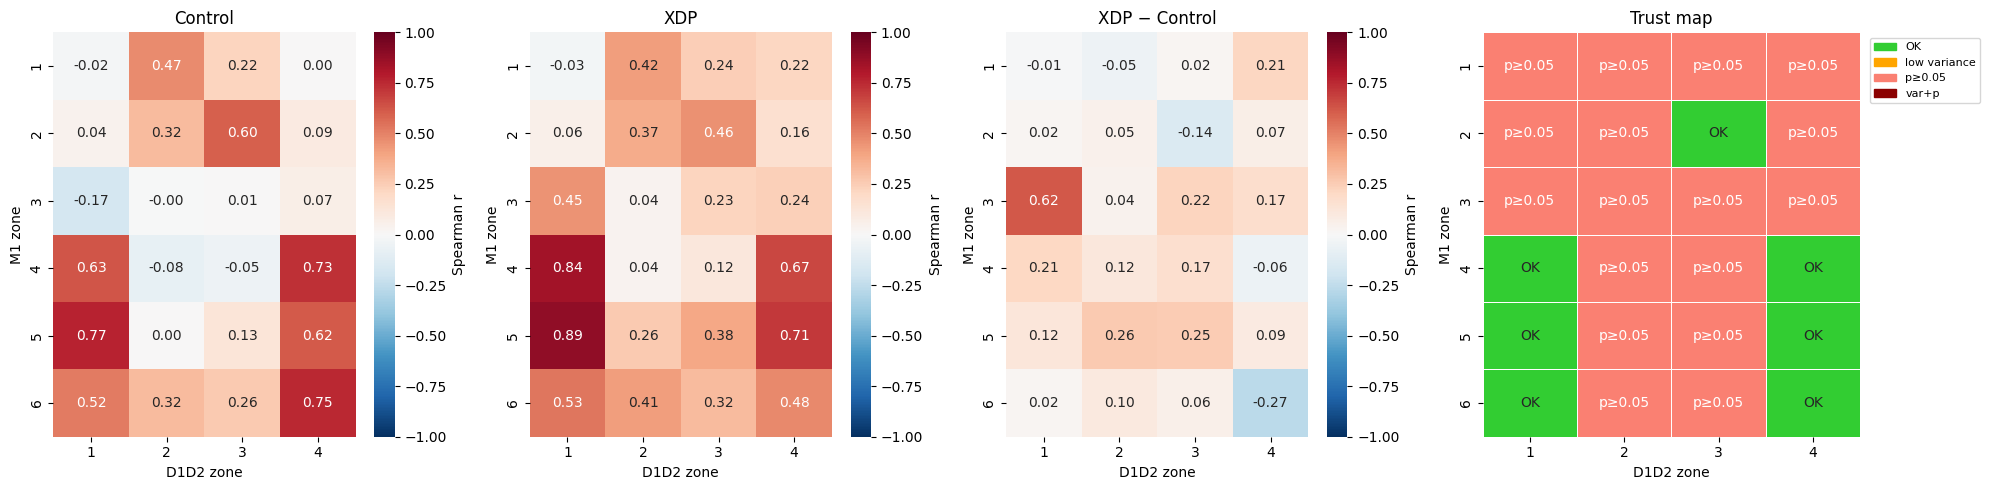

In [18]:
from scipy import stats
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def corr_and_pval(a, b):
    idx, cols = a.columns, b.columns
    corr = pd.DataFrame(index=idx, columns=cols, dtype=float)
    pval = pd.DataFrame(index=idx, columns=cols, dtype=float)
    for i in idx:
        for j in cols:
            corr.loc[i,j], pval.loc[i,j] = stats.spearmanr(a[i], b[j])
    return corr, pval

corr_ctrl, pval_ctrl = corr_and_pval(m1.loc[ctrl_donors], d1d2.loc[ctrl_donors])
corr_xdp,  pval_xdp  = corr_and_pval(m1.loc[xdp_donors],  d1d2.loc[xdp_donors])
corr_diff = corr_xdp - corr_ctrl

display(corr_ctrl)
display(corr_xdp)
display(corr_diff)

var_ctrl = (m1.loc[ctrl_donors] > 0).mean() >= 0.1
var_xdp  = (m1.loc[xdp_donors]  > 0).mean() >= 0.1

# reason matrix: 0=OK, 1=low var, 2=p≥0.05, 3=both
low_var = pd.DataFrame(
    (~var_ctrl | ~var_xdp).values[:, None] * np.ones((1, len(d1d2.columns))),
    index=m1.columns, columns=d1d2.columns
).astype(bool)
not_sig = (pval_ctrl >= 0.05) | (pval_xdp >= 0.05)
reason  = low_var.astype(int) + not_sig.astype(int) * 2
annot   = reason.replace({0:"OK", 1:"low var", 2:"p≥0.05", 3:"var+p"})

display(annot)

# plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
kw = dict(cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
          cbar_kws={"label": "Spearman r"})
for ax, mat, title in zip(axes[:3],
                           [corr_ctrl, corr_xdp, corr_diff],
                           ["Control", "XDP", "XDP − Control"]):
    sns.heatmap(mat, ax=ax, **kw)
    ax.set(title=title, xlabel="D1D2 zone", ylabel="M1 zone")

sns.heatmap(reason, cmap=ListedColormap(["limegreen","orange","salmon","darkred"]),
            vmin=0, vmax=3, annot=annot, fmt="s", cbar=False,
            linewidths=0.5, linecolor="white", ax=axes[3])
axes[3].set(title="Trust map", xlabel="D1D2 zone", ylabel="M1 zone")
axes[3].legend(handles=[
    mpatches.Patch(color=c, label=l) for c, l in zip(
        ["limegreen","orange","salmon","darkred"],
        ["OK","low variance","p≥0.05","var+p"])
], bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


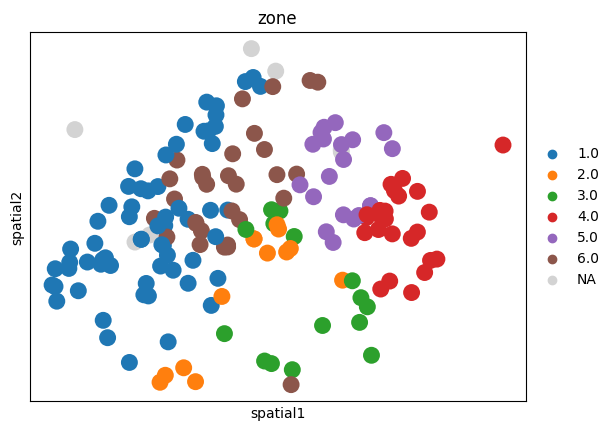

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


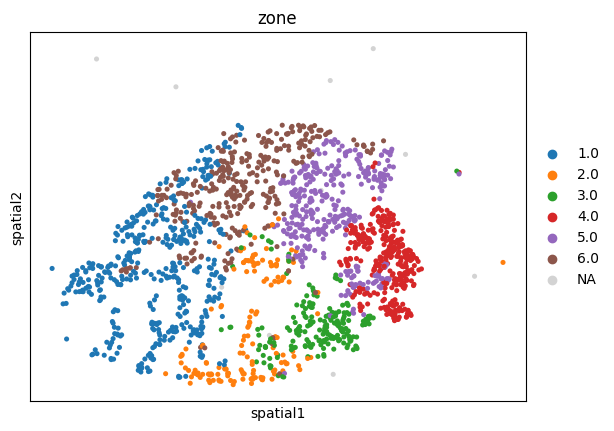

In [ ]:
sample="UMBEB24013"#"MS9244"#"MS30499"
sc.pl.embedding(adata_d1d2[adata_d1d2.obs["donor_id"] == sample], basis="spatial", color="zone")
sc.pl.embedding(adata_m1[adata_m1.obs["donor_id"] == sample], basis="spatial", color="zone")

# ---------------------------

# Other

In [ ]:
sc.pp.filter_genes(adata_d1d2, min_cells=1) 
sc.pp.normalize_total(adata_d1d2, target_sum=1e4)
sc.pp.log1p(adata_d1d2)
adata_d1d2.layers["log1p_norm"] = adata_d1d2.X.copy()

sc.pp.filter_genes(adata_m1, min_cells=1) 
sc.pp.normalize_total(adata_m1, target_sum=1e4)
sc.pp.log1p(adata_m1)
adata_m1.layers["log1p_norm"] = adata_m1.X.copy()

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


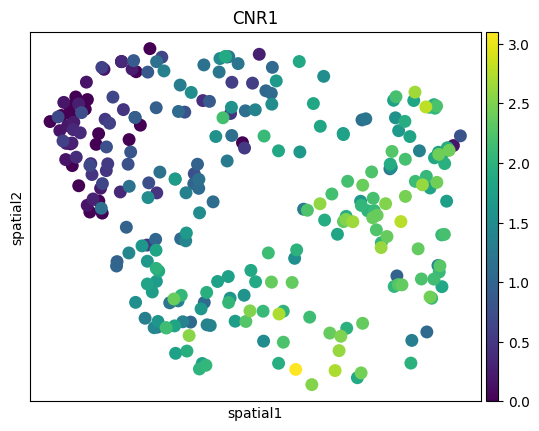

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


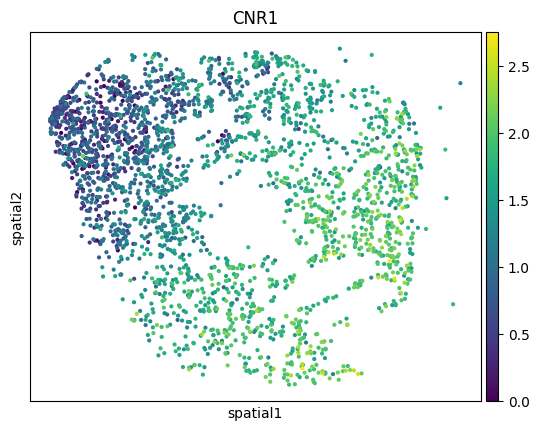

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


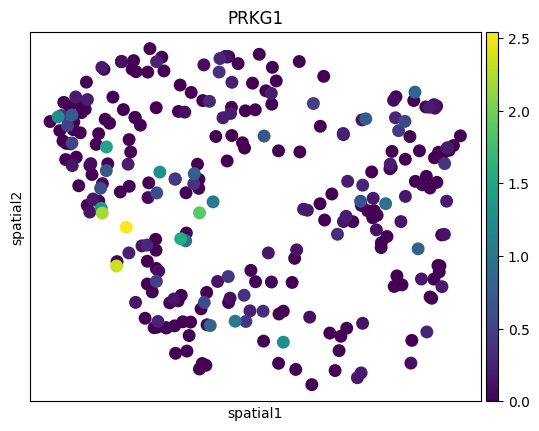

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


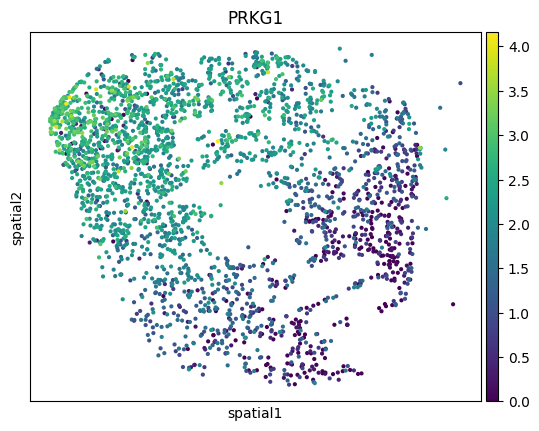

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


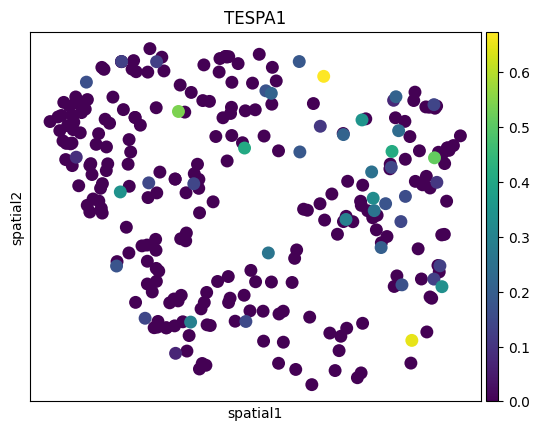

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


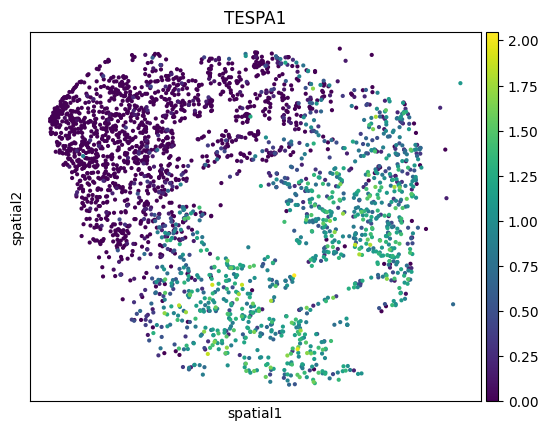

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


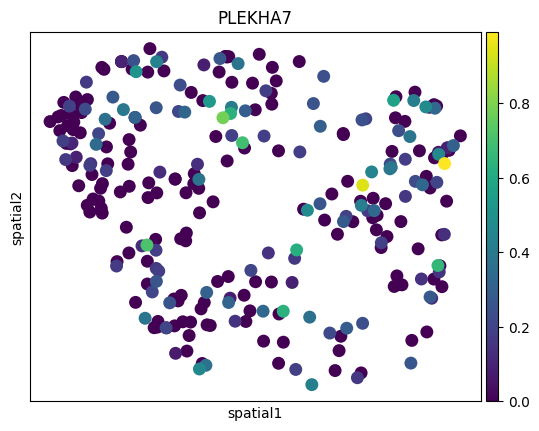

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


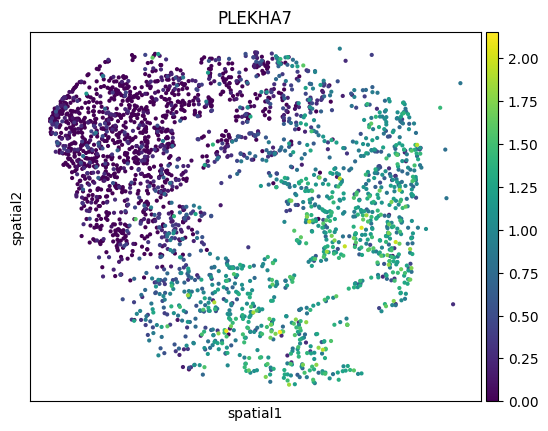

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


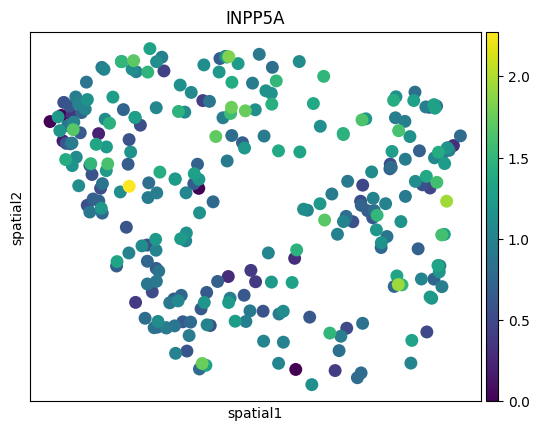

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


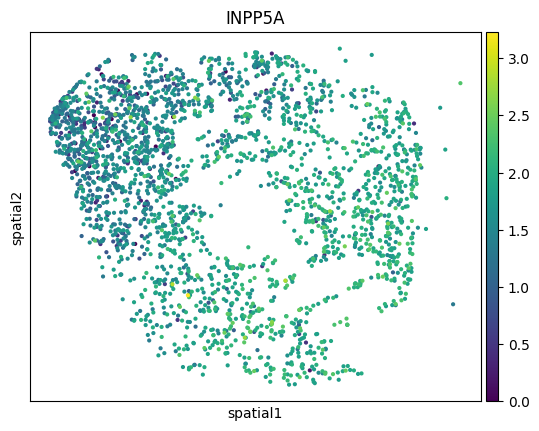

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


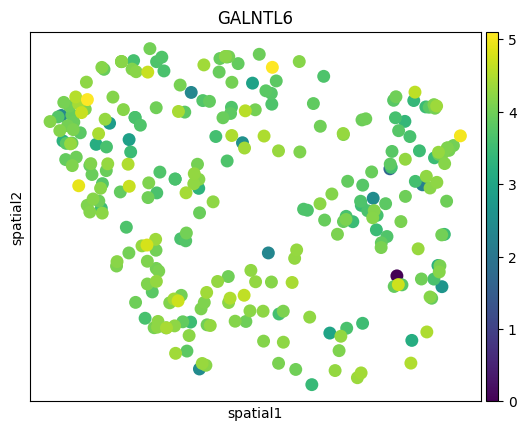

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


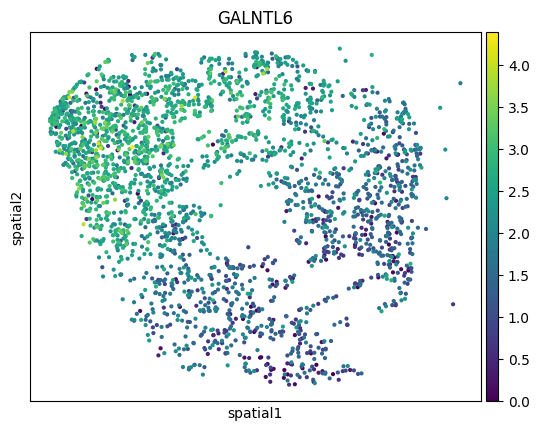

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


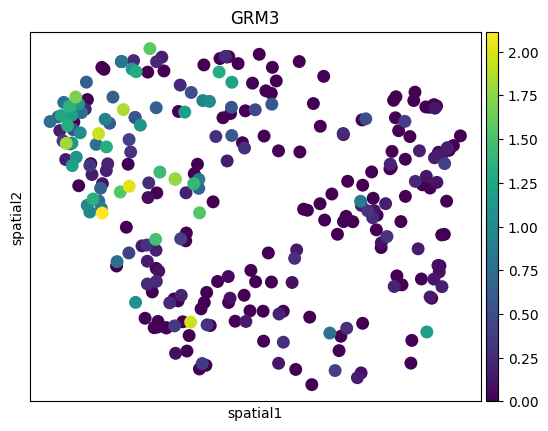

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


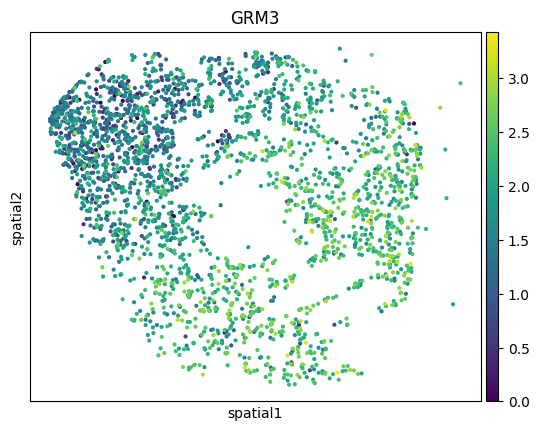

In [ ]:
for g in ["CNR1", "PRKG1", "TESPA1", "PLEKHA7", "INPP5A", "GALNTL6", "GRM3"]:
    sc.pl.embedding(adata_d1d2[adata_d1d2.obs["donor_id"] == adata_d1d2.obs["donor_id"].unique()[2]], basis="spatial", color=g, layer="log1p_norm")
    sc.pl.embedding(adata_m1[adata_m1.obs["donor_id"] == adata_m1.obs["donor_id"].unique()[2]], basis="spatial", color=g, layer="log1p_norm")

In [ ]:
# r('''
# library(qs); library(Seurat)
# sobj <- qread("/home/gdallagl/myworkdir/XDP/data/BICAN/ESPN_6_zones_reordered.qs")
# print(class(sobj))
# print(sobj)
# print(colnames(sobj@meta.data))
# head(sobj@meta.data)
# ''')